In [49]:
import geomodel_toolbox
import importlib

importlib.reload(geomodel_toolbox)

<module 'geomodel_toolbox' from 'c:\\Users\\ethan\\MSc-Thesis\\GeoModel\\geomodel_toolbox.py'>

In [2]:
import numpy as np
import pandas as pd

In [3]:
#  ====
# Inputs for creating strat model with gempy
#  ====
#dummy: xyz values are taken from gempy outputs
x_lims = (369702.8, 374398.9)
y_lims = (407778.9, 411690.2)
z_lims = (350, -2500)

resolution = [100, 100, 150]   # nx, ny, nz
 
strat_azimuth = 135 #deg
strat_dip = 10 #deg

#  ====
# Inputs for fracture map
#  ====

aperture = [50, 50] #[m] [MEAN, STD]
radius = [1000, 100] #[m] [MEAN, STD]
azimuth = [45, 10] #[deg] [MEAN, STD]

density = 5e-9 #[fractures/m3]

In [4]:
#geomodel_toolbox.create_strat_model(x_lims, y_lims, z_lims, resolution, strat_azimuth, strat_dip)

c:\Users\ethan\MSc-Thesis\GeoModel\geomodel_toolbox.py:266: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


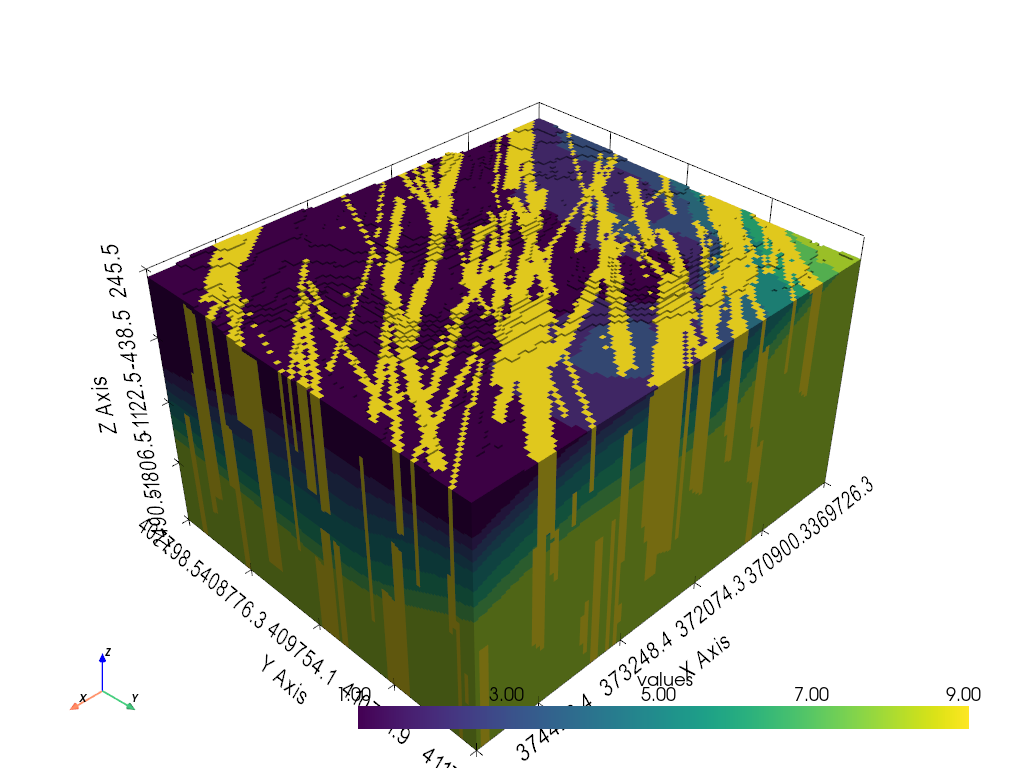

In [5]:
# Import previously defined topo+strat model
lith_topo, x_array, y_array, z_array= geomodel_toolbox.import_strat_model(show_plot=False)

# Generate fracture model based on inputs
mask, df = geomodel_toolbox.generate_fracture_model(x_array, y_array, z_array, aperture, radius, azimuth, density, show_plot=False)

# Combine to get topo+strat+frac model
geomodel = lith_topo.copy()
geomodel[(lith_topo > 0) & mask] = lith_topo.max()+1

# Plot results
geomodel_toolbox.plot_3d_model(geomodel, x_array, y_array, z_array)

In [50]:
# Define rock properties for easy access
ROCK_TYPES = {
    "M": {"poro": 0.2, "permx": 50},
    "B": {"poro": 0.02, "permx": 1e-2},
    "F": {"poro": 0.1, "permx": 1e3}
}

# Export to grid eclipse
grid = geomodel_toolbox.export_grdecl_from_geomodel(
    geomodel=geomodel,
    x_array=x_array,
    y_array=y_array,
    z_array=z_array,
    rock_types=ROCK_TYPES,
    out_file="grid.grdecl"
)

z_array_flat = -z_array[z_array < 0][::-1]

In [34]:
#Export well file for visualisation (separate from the geological model)
geomodel_toolbox.export_wells_as_dev()

Created vertical_wells.dev


In [35]:
#print resolutions: 
print('x res:', np.round(x_array[1]-x_array[0], 1), 'm')
print('y res:', np.round(y_array[1]-y_array[0], 1), 'm')
print('z res:', np.round(z_array[1]-z_array[0], 1), 'm')

print(z_array_flat.shape)

x res: 47.0 m
y res: 39.1 m
z res: 19.0 m
(132,)


In [36]:
z_array

array([-2.4905e+03, -2.4715e+03, -2.4525e+03, -2.4335e+03, -2.4145e+03,
       -2.3955e+03, -2.3765e+03, -2.3575e+03, -2.3385e+03, -2.3195e+03,
       -2.3005e+03, -2.2815e+03, -2.2625e+03, -2.2435e+03, -2.2245e+03,
       -2.2055e+03, -2.1865e+03, -2.1675e+03, -2.1485e+03, -2.1295e+03,
       -2.1105e+03, -2.0915e+03, -2.0725e+03, -2.0535e+03, -2.0345e+03,
       -2.0155e+03, -1.9965e+03, -1.9775e+03, -1.9585e+03, -1.9395e+03,
       -1.9205e+03, -1.9015e+03, -1.8825e+03, -1.8635e+03, -1.8445e+03,
       -1.8255e+03, -1.8065e+03, -1.7875e+03, -1.7685e+03, -1.7495e+03,
       -1.7305e+03, -1.7115e+03, -1.6925e+03, -1.6735e+03, -1.6545e+03,
       -1.6355e+03, -1.6165e+03, -1.5975e+03, -1.5785e+03, -1.5595e+03,
       -1.5405e+03, -1.5215e+03, -1.5025e+03, -1.4835e+03, -1.4645e+03,
       -1.4455e+03, -1.4265e+03, -1.4075e+03, -1.3885e+03, -1.3695e+03,
       -1.3505e+03, -1.3315e+03, -1.3125e+03, -1.2935e+03, -1.2745e+03,
       -1.2555e+03, -1.2365e+03, -1.2175e+03, -1.1985e+03, -1.17

In [ ]:
import pandas as pd
import numpy as np
import rasterio

# ----------------------------
# 1. Load inputs
# ----------------------------
wells = pd.read_csv("gempy_inputs/borehole_data.csv")

dem_path = "subset_dem.tif"
dem_src = rasterio.open(dem_path)

# ----------------------------
# 2. Helper: sample DEM
# ----------------------------
def get_dem_elevation(x, y):
    """Return DEM elevation at (x,y)."""
    row, col = dem_src.index(x, y)
    return dem_src.read(1)[row, col]


# ----------------------------
# 3. Grid helpers
# ----------------------------
dx = x_array[1] - x_array[0]
dy = y_array[1] - y_array[0]
dz = z_array_flat[1] - z_array_flat[0]

# z_array is assumed to be the CROPPED version
# exported to GRDECL, e.g.
#
# [0, -10, -20, -30, ...]
#
# K=1 corresponds to the first layer in this array.

def xyz_to_ijk(x, y, z):
    """Convert coordinates to Eclipse-style 1-based indices."""

    i = int(np.argmin(np.abs(x_array - x))) + 1
    j = int(np.argmin(np.abs(y_array - y))) + 1
    k = int(np.argmin(np.abs(z_array_flat - z))) + 1

    return i, j, k


# ----------------------------
# 4. Convert well intervals
# ----------------------------
completions = []

for _, w in wells.iterrows():

    name = w["name"]
    x = w["x"]
    y = w["y"]

    # depths below surface
    z_top = w["casing"]
    z_bottom = w["depth"]

    # DEM elevation at wellhead
    z_surface = get_dem_elevation(x, y)

    # convert to absolute elevations
    z_top_abs = np.abs(z_surface - z_top)       #added abs() because depth is positive
    z_bot_abs = np.abs(z_surface - z_bottom)

    z_high = min(z_top_abs, z_bot_abs)
    z_low = max(z_top_abs, z_bot_abs)

    # --------------------------------------------------
    # exported model only contains z <= 0
    # --------------------------------------------------

    # skip wells entirely above datum
    if z_low < 0:
        continue

    # truncate completion if top is above datum
    z_high = max(z_high, 0.0)

    # convert to K indices
    k1 = int(np.argmin(np.abs(z_array_flat - z_high))) + 1
    k2 = int(np.argmin(np.abs(z_array_flat - z_low))) + 1

    if k1 > k2:
        k1, k2 = k2, k1

    # ensure indices stay inside model
    k1 = max(1, min(k1, len(z_array_flat)))
    k2 = max(1, min(k2, len(z_array_flat)))

    # I/J location
    i, j, _ = xyz_to_ijk(x, y, z_array_flat[0])

    completions.append((name, i, j, k1, k2))


# ----------------------------
# 5. Write Eclipse COMPDAT file
# ----------------------------
with open("sch.inc", "w") as f:

    f.write("--perforations in Eclipse format I, J, K1-K2, 1-based indices\n")
    f.write("COMPDAT\n")

    for name, i, j, k1, k2 in completions:
        f.write(f"PRD-{name} {i} {j} {k1} {k2} /\n")

    f.write("/\n")

print(f"sch.inc written with {len(completions)} completions.")

sch.inc written with 37 completions.
